In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("bp_summary_classified.csv")
print("Shape:", df.shape)
df.head()

Shape: (1580, 47)


,source_file,test_begin,age,sex,date_of_birth,all_avg_sys,all_avg_dia,day_avg_sys,day_avg_dia,day_bp_threshold_sys,...,bp_cv_all_dia_pct,bp_cv_day_sys_pct,bp_cv_day_dia_pct,bp_cv_night_sys_pct,bp_cv_night_dia_pct,contents,diagnostics,aasi_sys,readings_count,health_label
0,ID_0001_cleaned.pdf,2024/03/26 14:01:00,73.0,Male,1951/01/18,132.1,63.9,139.4,71.1,135.0,...,21.2,8.5,15.1,6.6,21.1,CHIFFRES > NLE ET DES PICS A 170/90 MMHG . TRA...,PROFIL TENSIONNEL ELEVE SURTOUT EN PERIODE DIU...,0.17,34,not
1,ID_0002_cleaned.pdf,2021/06/14 10:31:00,68.0,Female,1953/11/19,111.6,58.3,115.3,60.7,135.0,...,15.8,10.8,15.9,5.3,10.0,111/58 MMHG . DR BEN MILED MEHDI,PROFIL TENSIONNEL PARFAITMENT NORMAL AUSSI BIE...,0.56,42,healthy
2,ID_0003_cleaned.pdf,2023/03/04 09:30:00,50.0,Male,1973/03/14,126.1,75.8,131.6,82.6,135.0,...,17.3,7.0,9.1,11.3,13.5,NORMAL. A SURVEILLER SOUS MEUSURES DIETETIQUES...,PROFIL TENSIONNEL LIMITE EN PERIODE DIURNE A V...,0.20,24,not
3,ID_0004_cleaned.pdf,2023/03/08 09:01:00,60.0,Male,1963/08/10,132.3,71.5,138.8,75.0,135.0,...,15.5,10.2,13.3,14.5,14.9,NLE ET DES PICS A 170/89 MMHG. PROFIL NOCTURNE...,PROFIL TENSIONNEL ELEVE EN PERIODE DIURNE A VE...,0.48,42,not
4,ID_0005_cleaned.pdf,2021/07/31 11:00:00,38.0,Female,1983/02/01,131.2,82.3,128.8,82.0,135.0,...,16.8,11.7,16.0,11.9,18.5,NOCTURNE FRANCHEMENT ELEVE A VEC UNE MOYENNE A...,PROFIL TENSIONNEL LIMITE EN PERIODE DIURNE A V...,0.32,42,not


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1580 entries, 0 to 1579
Data columns (total 47 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   source_file                  1580 non-null   object 
 1   test_begin                   1579 non-null   object 
 2   age                          1562 non-null   float64
 3   sex                          1579 non-null   object 
 4   date_of_birth                1579 non-null   object 
 5   all_avg_sys                  1579 non-null   float64
 6   all_avg_dia                  1579 non-null   float64
 7   day_avg_sys                  1579 non-null   float64
 8   day_avg_dia                  1579 non-null   float64
 9   day_bp_threshold_sys         1579 non-null   float64
 10  day_bp_threshold_dia         1579 non-null   float64
 11  night_avg_sys                1579 non-null   float64
 12  night_avg_dia                1579 non-null   float64
 13  night_bp_threshold

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct}).query("missing_count > 0").sort_values('missing_%', ascending=False)

,missing_count,missing_%
circadian_sys_night_des_pct,132,8.35
circadian_dia_night_des_pct,132,8.35
circadian_normal_range,132,8.35
aasi_sys,38,2.41
age,18,1.14
contents,2,0.13
day_avg_sys,1,0.06
all_avg_dia,1,0.06
all_avg_sys,1,0.06
test_begin,1,0.06


In [ ]:
df.describe()

,count,mean,std,min,25%,50%,75%,max
age,1562.0,50.077465,12.129602,15.0,42.000,50.00,58.00,97.00
all_avg_sys,1579.0,129.729196,13.628167,95.7,120.000,128.20,137.65,203.50
all_avg_dia,1579.0,77.743319,10.739917,43.5,70.500,76.60,83.85,133.60
day_avg_sys,1579.0,133.772704,16.160740,0.0,124.400,133.00,142.30,204.70
day_avg_dia,1579.0,81.271881,12.220556,0.0,73.800,80.30,88.40,134.20
day_bp_threshold_sys,1579.0,135.427486,1.398543,135.0,135.000,135.00,135.00,140.00
day_bp_threshold_dia,1579.0,85.427486,1.398543,85.0,85.000,85.00,85.00,90.00
night_avg_sys,1579.0,119.958518,18.770842,0.0,110.000,119.30,129.60,201.90
night_avg_dia,1579.0,69.783914,12.968000,0.0,62.800,69.40,76.50,132.90
night_bp_threshold_sys,1579.0,120.000000,0.000000,120.0,120.000,120.00,120.00,120.00


health_label
not        965
healthy    615
Name: count, dtype: int64


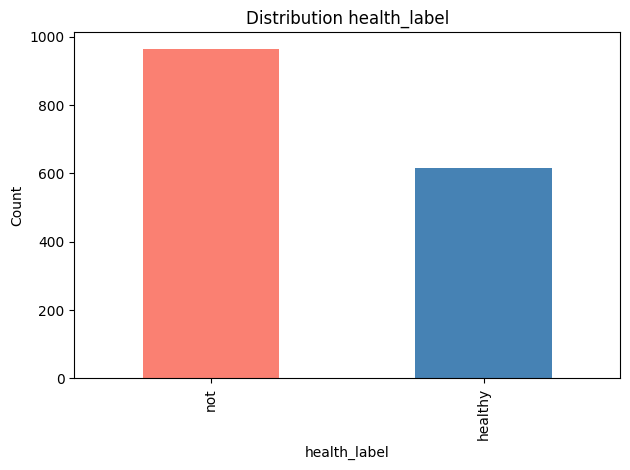

In [ ]:
print(df['health_label'].value_counts())
df['health_label'].value_counts().plot(kind='bar', color=['salmon', 'steelblue'], title='Distribution health_label')
plt.ylabel("Count")
plt.tight_layout()
plt.show()

sex
Male      805
Female    774
Name: count, dtype: int64

count    1562.000000
mean       50.077465
std        12.129602
min        15.000000
25%        42.000000
50%        50.000000
75%        58.000000
max        97.000000
Name: age, dtype: float64


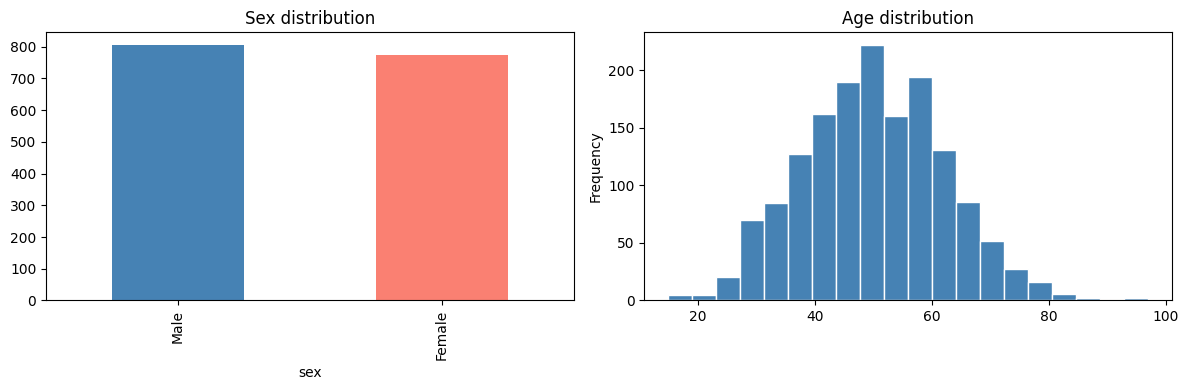

In [ ]:
print(df['sex'].value_counts())

print(df['age'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['sex'].value_counts().plot(kind='bar', ax=axes[0], title='Sex distribution', color=['steelblue', 'salmon'])
df['age'].plot(kind='hist', bins=20, ax=axes[1], title='Age distribution', color='steelblue', edgecolor='white')
plt.tight_layout()
plt.show()

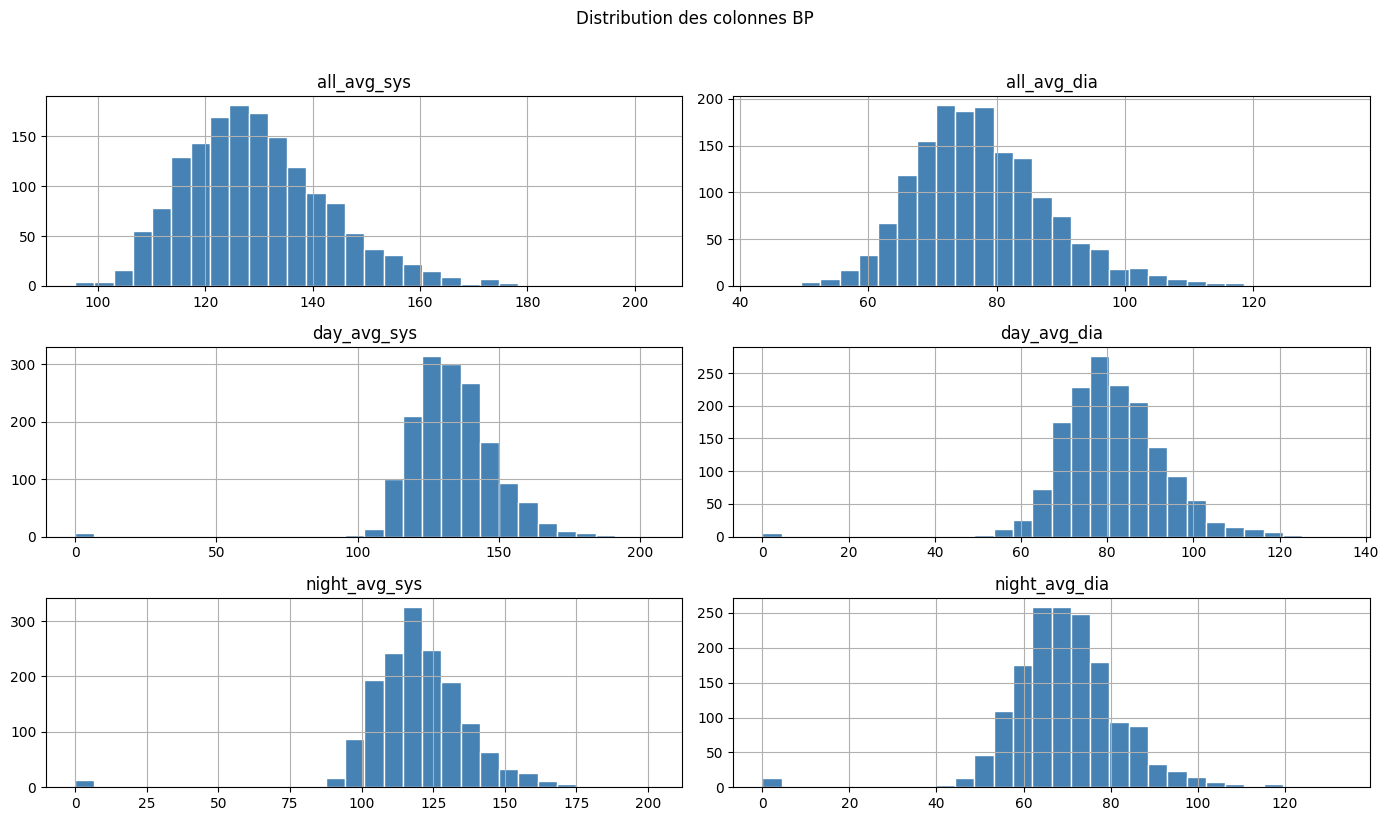

In [ ]:
bp_cols = ['all_avg_sys', 'all_avg_dia', 'day_avg_sys', 'day_avg_dia', 'night_avg_sys', 'night_avg_dia']
df[bp_cols].hist(bins=30, figsize=(14, 8), color='steelblue', edgecolor='white')
plt.suptitle("Distribution des colonnes BP", y=1.02)
plt.tight_layout()
plt.show()

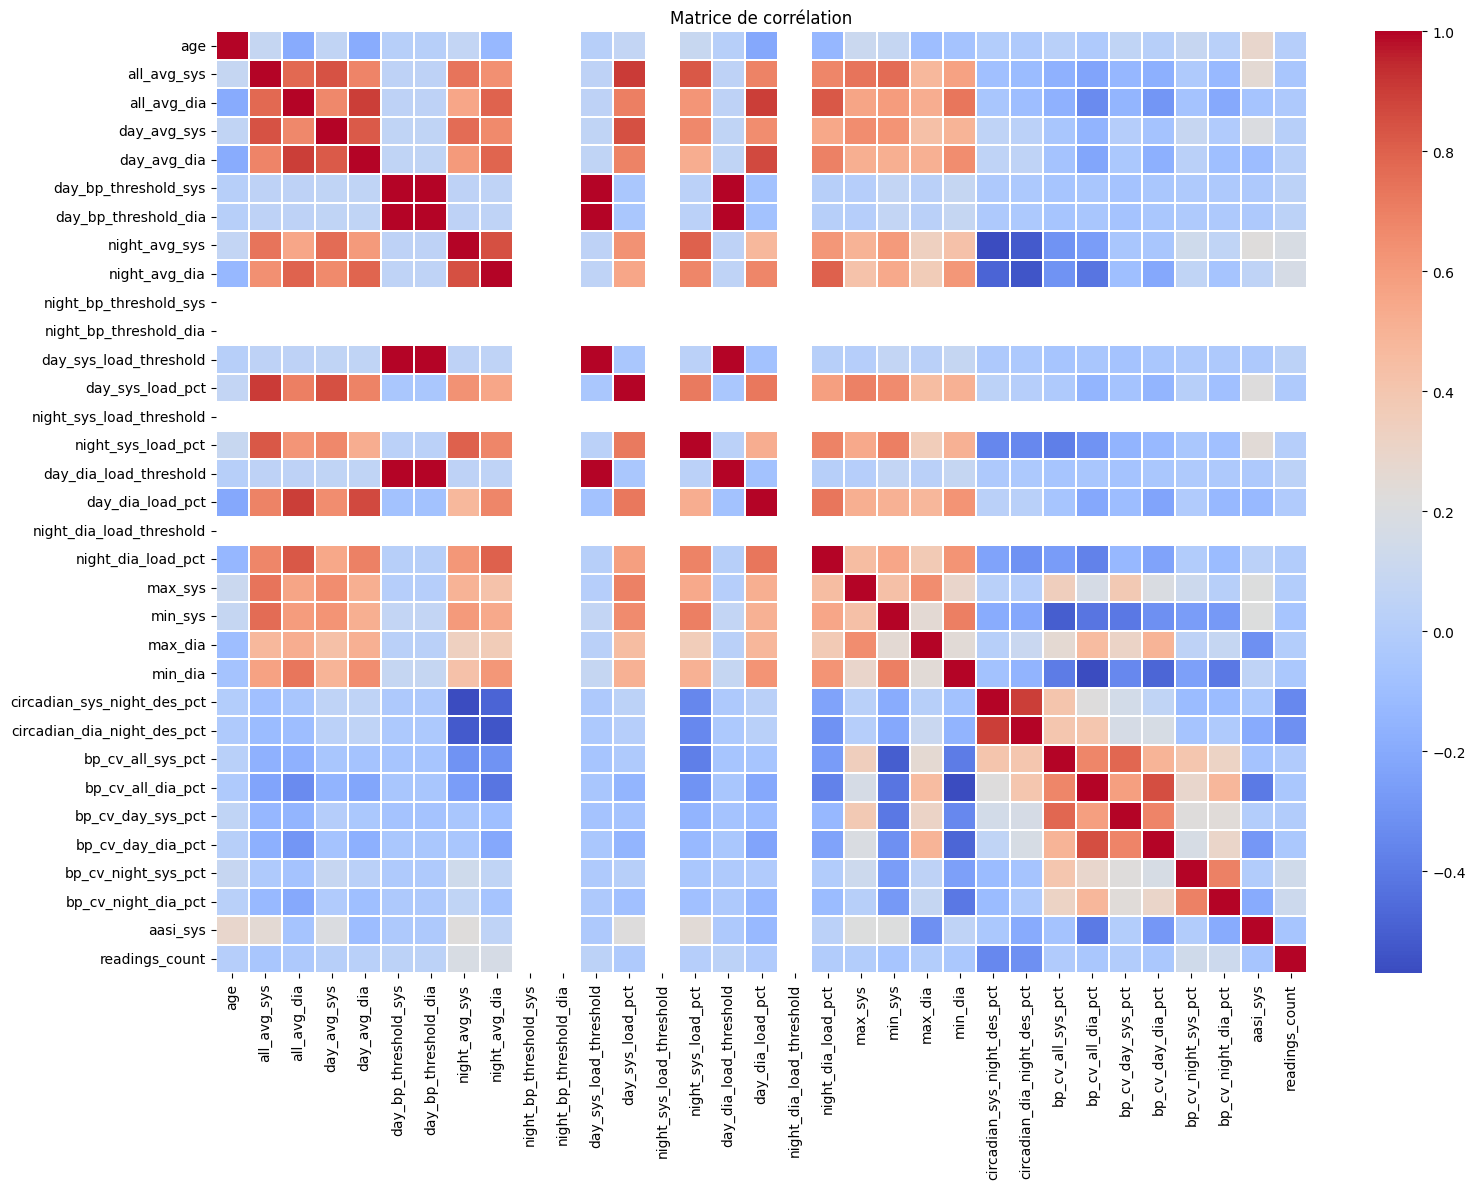

In [ ]:
plt.figure(figsize=(16, 12))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', linewidths=0.3)
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()

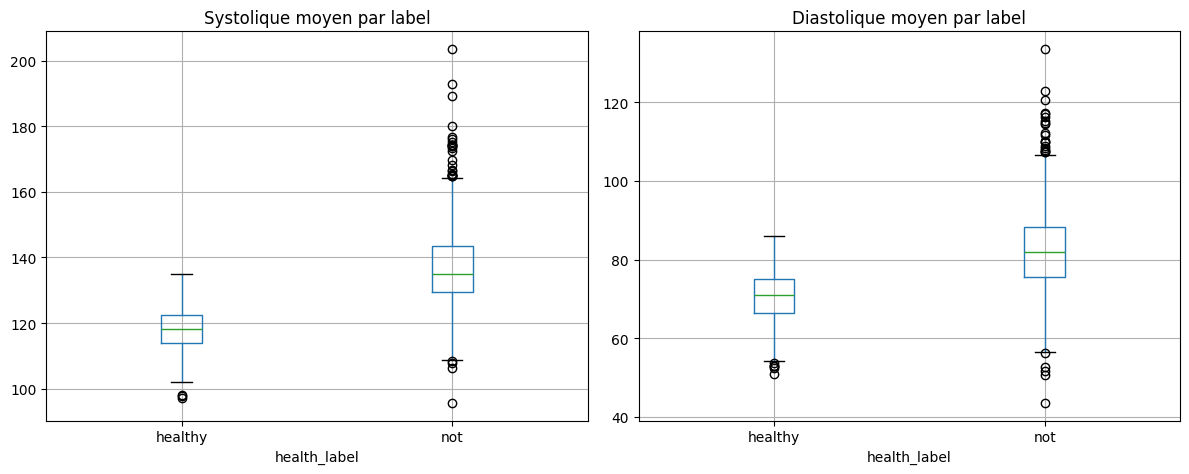

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df.boxplot(column='all_avg_sys', by='health_label', ax=axes[0])
df.boxplot(column='all_avg_dia', by='health_label', ax=axes[1])
axes[0].set_title('Systolique moyen par label')
axes[1].set_title('Diastolique moyen par label')
plt.suptitle("")
plt.tight_layout()
plt.show()